In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import folium

In [ ]:
# Load the dataset
df = pd.read_csv("/content/Real estate.csv")
# Display first 5 rows
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
# Display information about the dataset
df.info()
# Display statistical summary
df.describe()
# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


,0
No,0
X1 transaction date,0
X2 house age,0
X3 distance to the nearest MRT station,0
X4 number of convenience stores,0
X5 latitude,0
X6 longitude,0
Y house price of unit area,0


In [ ]:
# Select the features for clustering
features = df[['X2 house age',
               'X3 distance to the nearest MRT station',
               'X4 number of convenience stores',
               'X5 latitude',
               'X6 longitude',
               'Y house price of unit area']]
# Display the first 5 rows of the selected features
features.head()

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,32.0,84.87882,10,24.98298,121.54024,37.9
1,19.5,306.59470,9,24.98034,121.53951,42.2
2,13.3,561.98450,5,24.98746,121.54391,47.3
3,13.3,561.98450,5,24.98746,121.54391,54.8
4,5.0,390.56840,5,24.97937,121.54245,43.1


In [23]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Scale the selected features
scaled_data = scaler.fit_transform(features)

# Display the first 5 rows of the scaled data
scaled_data[:5]

array([[ 1.25562833, -0.79249504,  2.00740743,  1.12542986,  0.44876222,
        -0.00590088],
       [ 0.15708622, -0.61661163,  1.66750286,  0.91244418,  0.40113894,
         0.3105072 ],
       [-0.38779067, -0.41401527,  0.30788458,  1.48686011,  0.68818339,
         0.6857819 ],
       [-0.38779067, -0.41401527,  0.30788458,  1.48686011,  0.68818339,
         1.23765646],
       [-1.11722264, -0.54999673,  0.30788458,  0.83418808,  0.59293682,
         0.37673215]])

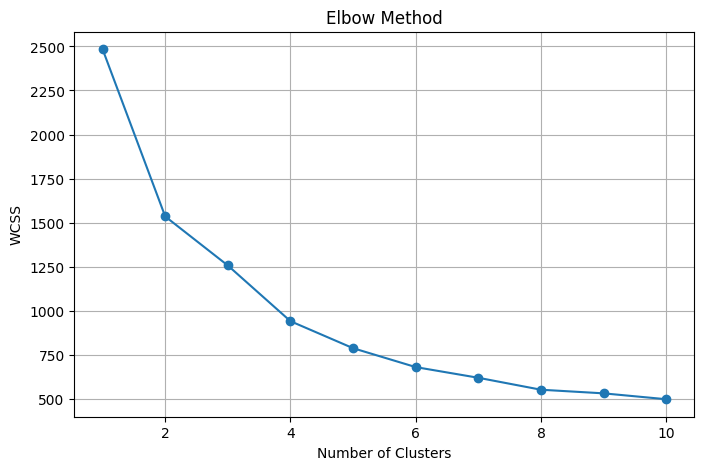

In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [25]:
from sklearn.cluster import KMeans

# Create the K-Means model
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit the model and predict the clusters
clusters = kmeans.fit_predict(scaled_data)

In [26]:
# Add cluster labels as a new column
df['Cluster'] = clusters

# Display the first 5 rows
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Cluster
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,2
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,1
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,1
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,1
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,1


In [27]:
from sklearn.decomposition import PCA

# Create a PCA object to reduce the data to 2 dimensions
pca = PCA(n_components=2)

# Transform the scaled data
pca_data = pca.fit_transform(scaled_data)

# Display the first 5 rows
pca_data[:5]

array([[-1.83729228,  1.6885482 ],
       [-1.6873172 ,  0.48650965],
       [-1.57101065, -0.2253957 ],
       [-1.823601  , -0.34490501],
       [-1.22182909, -0.95340128]])

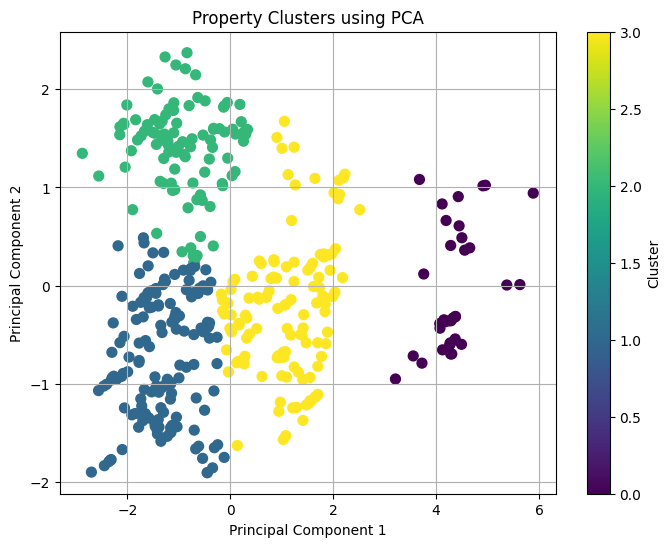

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)

plt.title("Property Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

In [29]:
# Create a map centered on the average latitude and longitude
map1 = folium.Map(
    location=[df['X5 latitude'].mean(), df['X6 longitude'].mean()],
    zoom_start=13
)

# Display the map
map1

In [31]:
colors = ['red', 'blue', 'green', 'purple', 'orange',
          'darkred', 'cadetblue', 'darkgreen', 'black', 'pink']

for _, row in df.iterrows():
    cluster = int(row['Cluster'])   # Convert cluster to an integer

    folium.CircleMarker(
        location=[row['X5 latitude'], row['X6 longitude']],
        radius=5,
        popup=f"""
        Cluster: {cluster}<br>
        House Price: {row['Y house price of unit area']}<br>
        House Age: {row['X2 house age']}
        """,
        color=colors[cluster],
        fill=True,
        fill_color=colors[cluster],
        fill_opacity=0.7
    ).add_to(map1)

map1

In [32]:
# Save the interactive map as an HTML file
map1.save("housing_clusters_map.html")

In [33]:
from google.colab import files

files.download("housing_clusters_map.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# Save the dataset with cluster labels
df.to_csv("clustered_housing_data.csv", index=False)

In [35]:
files.download("clustered_housing_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>